We will explore how to tidy up data on olympics medalists from the 2008 olympics. First, let's import our data. 

In [16]:
import pandas as pd

# We use the read_csv function to load the data into a DataFrame

df = pd.read_csv('olympics_08_medalists.csv')

#Let's get an initial look at our data. 

print(df)

          medalist_name male_archery female_archery male_athletics  \
0       Aaron Armstrong          NaN            NaN           gold   
1         Aaron Peirsol          NaN            NaN            NaN   
2      Abdullo Tangriev          NaN            NaN            NaN   
3     Abeer Abdelrahman          NaN            NaN            NaN   
4               Abhinav          NaN            NaN            NaN   
...                 ...          ...            ...            ...   
1870        Éver Banega          NaN            NaN            NaN   
1871  Ólafur Stefánsson          NaN            NaN            NaN   
1872      Óscar Brayson          NaN            NaN            NaN   
1873   Łukasz Pawłowski          NaN            NaN            NaN   
1874        Živko Gocić          NaN            NaN            NaN   

     female_athletics male_badminton female_badminton male_baseball  \
0                 NaN            NaN              NaN           NaN   
1                

Next, let us melt the data. We have too many columns with our initial dataset since there are so many sports. All of these sports could easily be combined into one column in which the relevant sport is listed in each row. Therefore, we will "melt" our dataframe to achieve this effect. 

In [3]:
#let's grab the column names
value_vars = [col for col in df.columns if col != 'medalist_name']

#and then use the "pd.melt" function to melt the data so that the many columns are consolidated into a single column
df_melted = pd.melt(
   df,
   id_vars=['medalist_name'],
   value_vars=value_vars,
   var_name='Sport',
   value_name='Medal'
)

This produces quite a few NaN values. We will want to clear these out since they are irrelevant to the data.

In [ ]:
#we use the dropna function to get rid of the NaN values (which we do not want because it makes the data messy)
df_melted = df_melted.dropna(subset=['Medal'])
#the reset_index function gets rid of index values who had their irrelevant data removed
df_melted = df_melted.reset_index(drop=True)

The athlete gender division and the name of the sport are combined into one column, so we use the split function to fix this. We can use the replace function to clean up parts of the code. 

In [ ]:
#We use the split function to seperate the gender division from the specific event in the 'Sport' column. Currently the two are combined, and by setting this to split the column into two at the first '_' it encounters, we can fix the issue. 
df_melted[['Gender', 'Sport']] = df_melted['Sport'].str.split('_', n=1, expand=True)

#to simplfy the code further, we use the replace function. We get rid of the written text and rerplace it with a symbol and add underscores in the place of spaces. 
df_melted['Sport'] = df_melted['Sport'].str.replace(' and ', ' & ')
df_melted['Sport'] = df_melted['Sport'].str.replace(' ', '_')
df_melted = df_melted.dropna(subset=['Medal']).reset_index(drop=True)
#Let's print the data that we have to far and take a look at it. Notice how much it has changed. 
print(df_melted)

            medalist_name                  Sport   Medal Gender
0            Bair Badënov                archery  bronze   male
1           Ilario Di Buò                archery  silver   male
2            Im Dong-hyun                archery    gold   male
3               Jiang Lin                archery  bronze   male
4          Lee Chang-hwan                archery    gold   male
...                   ...                    ...     ...    ...
1870        Steeve Guénot  greco-roman_wrestling    gold   male
1871  Yannick Szczepaniak  greco-roman_wrestling  bronze   male
1872       Yavor Yanakiev  greco-roman_wrestling  bronze   male
1873      Yury Patrikeyev  greco-roman_wrestling  bronze   male
1874         Zoltán Fodor  greco-roman_wrestling  silver   male

[1875 rows x 4 columns]


Let's explore our cleaned data in graphs. Below is the code for some graphs created with the data. 

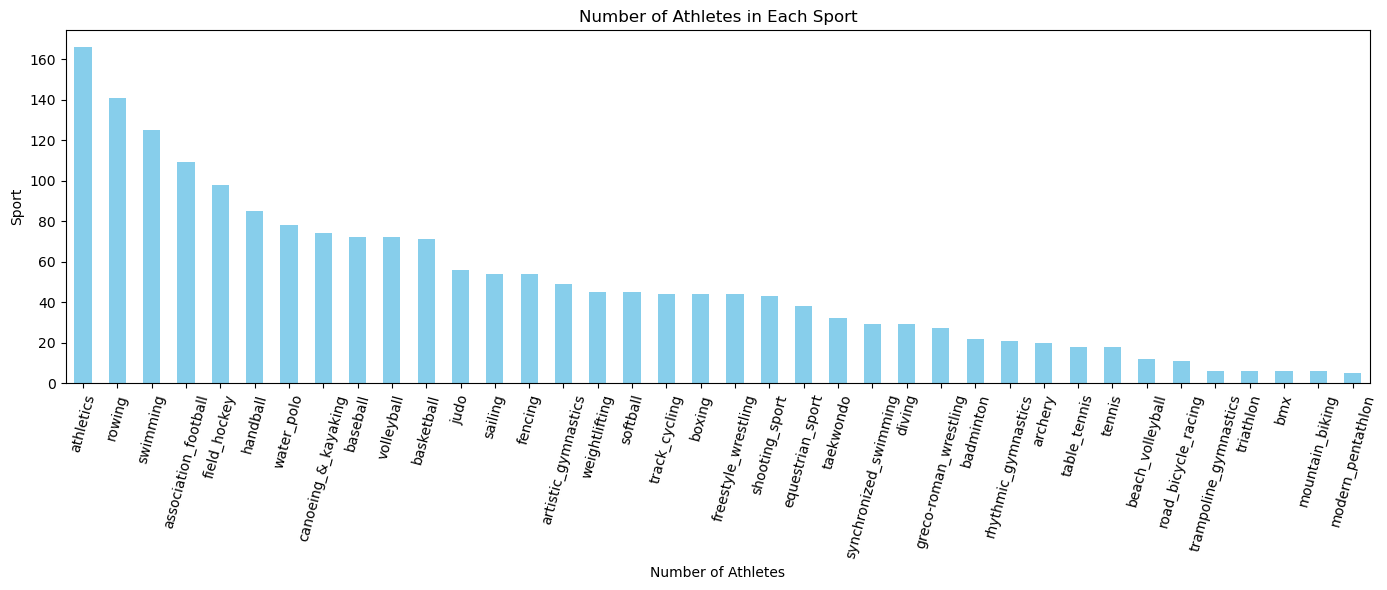

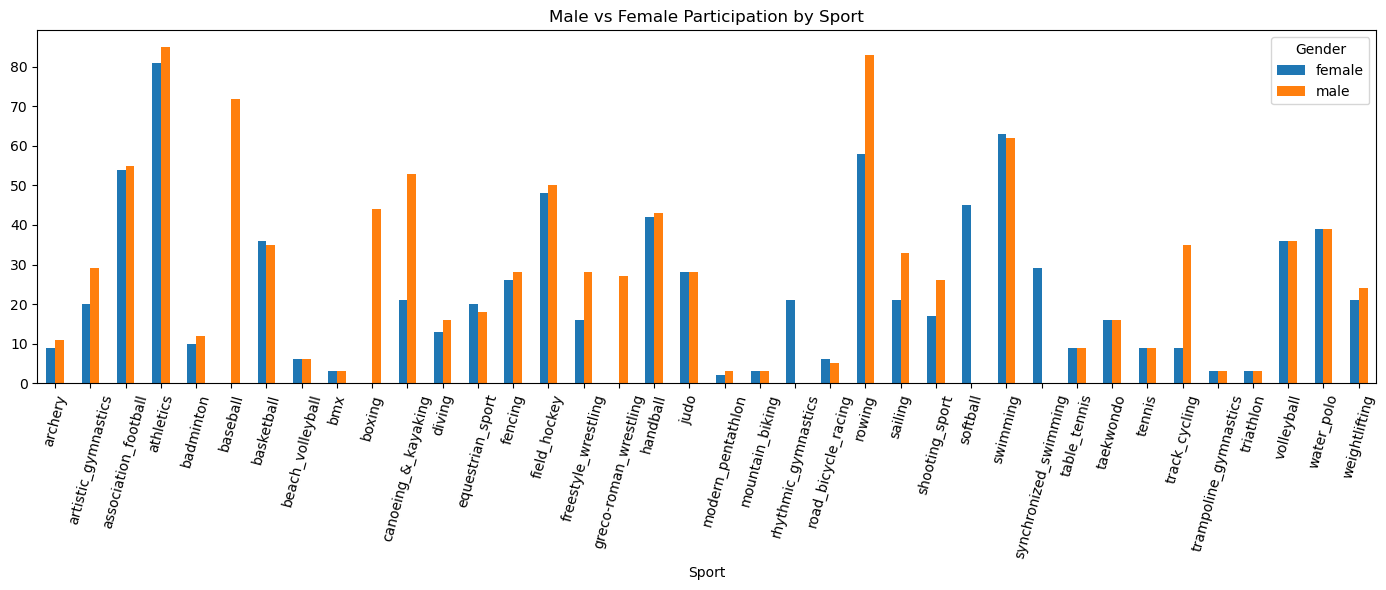

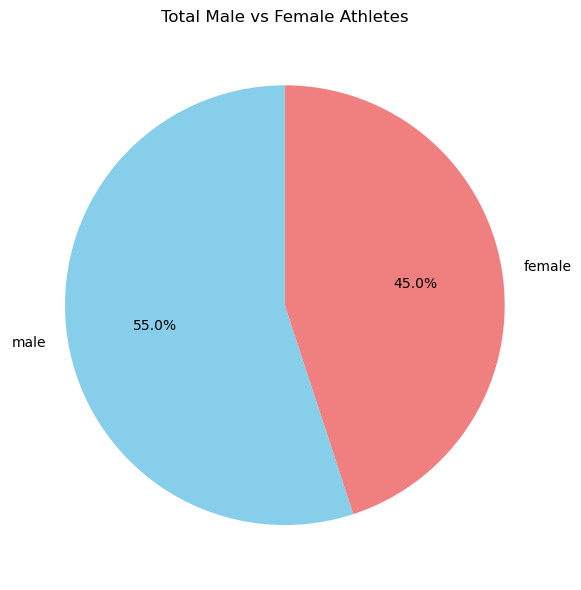

In [ ]:
# Now we are going to make our charts. First, let's retrieve the data we want to graph using the value_counts() function.
# We will first make a graph of the number of athletes. 

sport_counts = df_melted['Sport'].value_counts()

import matplotlib.pyplot as plt

# We make a bat graph for the number of athletes in each sport division. 
plt.figure(figsize=(14, 6))
sport_counts.plot(kind='bar', color='skyblue')

# We give our graph a title and axis labels. 
plt.title('Number of Athletes in Each Sport')
plt.xlabel('Number of Athletes')
plt.ylabel('Sport')

# We rotate the labels of the x-axis to make them clearer. 
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


# We will also make a graph about the distribution of different athletes by gender in each sport. We will use the value_counts() function to get this data.
gender_counts = df_melted['Gender'].value_counts()

# Here, we write code to include two variables on the graph using the 'groupby' function
gender_sport_counts = df_melted.groupby(['Sport', 'Gender']).size().unstack(fill_value=0)

# Here is the code to produce the graph.
gender_sport_counts.plot(kind='bar', figsize=(14, 6))
plt.title('Male vs Female Participation by Sport')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# We can use figsize to adjust the size. 
plt.figure(figsize=(6, 6))

# If we want to look at the breakdown of athletes at the Olympics by gender across all divisions, we can make a pie chart using the following code.
gender_counts.plot(
    kind='pie',
    autopct='%1.1f%%',   # this show percentages
    startangle=90,       # we rorate for a better layout
    colors=['skyblue', 'lightcoral']
)

#we add a plot title and labels
plt.title('Total Male vs Female Athletes')
plt.ylabel('')  

plt.tight_layout()
plt.show()


We can also portray this information using an aggregate function on a pivot table. This pivot table looks at sports players by gender. 

In [17]:


pivot_table = pd.pivot_table(
   df_melted,
   index='Sport',
   columns='Gender',
   values='Medal',
   aggfunc='count',
   fill_value=0
)


print(pivot_table)


Gender                 female  male
Sport                              
archery                     9    11
artistic_gymnastics        20    29
association_football       54    55
athletics                  81    85
badminton                  10    12
baseball                    0    72
basketball                 36    35
beach_volleyball            6     6
bmx                         3     3
boxing                      0    44
canoeing_&_kayaking        21    53
diving                     13    16
equestrian_sport           20    18
fencing                    26    28
field_hockey               48    50
freestyle_wrestling        16    28
greco-roman_wrestling       0    27
handball                   42    43
judo                       28    28
modern_pentathlon           2     3
mountain_biking             3     3
rhythmic_gymnastics        21     0
road_bicycle_racing         6     5
rowing                     58    83
sailing                    21    33
shooting_sport             1